# Data Curation for PROTAC-Splitter

## Setup and Imports

In [49]:
import os
import sys
import re
from typing import Mapping, Literal, Callable, List, ClassVar, Any, Tuple, Dict
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw
from rdkit import RDLogger
from rdkit import rdBase

if 'ipykernel' in sys.modules:
    from tqdm.auto import tqdm  # for notebooks
    from IPython.display import display
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        display(*args)
    else:
        print(*args)

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

data_dir = os.path.join(os.getcwd(), 'data')

## Utilities

SMILES canonization functions:

In [50]:
def canonize_smiles(smiles: str) -> str:
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except:
        return np.nan

# NOTE: It might not work for complex patterns: https://github.com/rdkit/rdkit/discussions/6929
def clean_smarts(smarts: str) -> str:
    """
    Cleans a SMARTS string by converting it to canonical SMARTS representation.

    Args:
        smarts (str): The input SMARTS string.

    Returns:
        str: The cleaned SMARTS string.
    """
    mol = Chem.MolFromSmarts(smarts)

    if mol is not None:
        canonical_smarts = Chem.MolToSmarts(Chem.MolFromSmiles(Chem.MolToSmiles(mol)))
        return canonical_smarts
    else:
        # Handle the case when the input SMARTS is invalid
        return np.nan

When splitting, we are also interested in labelling the "directionality" of the sub-structures, so that we can easily tell which substructure is the "warhead" (binding to the POI) and which is the "E3 ligand".

To this end, we now define and fix constant the IDs of the two attachment points:

In [51]:
POI_ATTACHMENT_ID = 1
E3_ATTACHMENT_ID = 2

Import the function to merge the SMILES substructures back into a single PROTAC. Useful for checking correctness of the splitting process.

Then define a function to indeed check all combinations.

In [52]:
# Enable debug logging
import logging

logging.basicConfig(level=logging.INFO)

In [53]:
import sys

sys.path.append(os.path.join(os.getcwd(), 'protac_splitter'))

from protac_splitter.protac_cheminformatics import reassemble_protac
from protac_splitter.evaluation import check_substructs

# Example usage
poi_smiles = '[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1'
linker_smiles = '[*:2]C(=O)CCCCCCCCCC[*:1]'
e3_smiles = '[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C'

merged_smiles, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, 'single', 'single')
print(merged_smiles)
print('-' * 80)

merged_smiles, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, 'single', 'double')
print(merged_smiles)
print('-' * 80)

merged_smiles, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, 'single', 'triple')
print(merged_smiles)
print('-' * 80)

# Example usage
protac_smiles = 'C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C=CCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1'
poi_smiles = '[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1'
linker_smiles = '[*:2]C(=O)CCCCCCCCCC[*:1]'
e3_smiles = '[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C'

correct, bond_types = check_substructs(protac_smiles, poi_smiles, linker_smiles, e3_smiles, return_bond_types=True)

assmbl_protac, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, **bond_types)
print(correct, bond_types)
print(assmbl_protac == protac_smiles)

C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
--------------------------------------------------------------------------------
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C=CCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
--------------------------------------------------------------------------------
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C#CCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
--------------------------------------------------------------------------------
True {'e3_bond_type': 'single', 'poi_bond_type': 'double'}
True


## Load Raw Datasets

From [PROTAC-DB paper](https://academic.oup.com/nar/article/49/D1/D1381/5917660?login=false#:~:text=For%20linkers%2C%20only%20the%202D%20structures%2C%20compound%20IDs%20and%20targeted%20proteins%20are%20shown%20in%20the%20datasheet.%20The%20%E2%80%98R1%E2%80%99%20and%20%E2%80%98R2%E2%80%99%20in%20the%20structures%20represent%20the%20sites%20that%20conjugate%20warheads%20and%20E3%20ligands%2C%20respectively.):

> For linkers, only the 2D structures, compound IDs and targeted proteins are shown in the datasheet. The ‘R1’ and ‘R2’ in the structures represent the sites that conjugate warheads and E3 ligands, respectively.

In [54]:
protac_pedia_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-Pedia.csv')).reset_index(drop=True)
protac_db_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB.csv')).reset_index(drop=True)
protac_db_linker_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-Linkers.csv')).reset_index(drop=True)
protac_db_e3_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-E3-Ligands.csv')).reset_index(drop=True)
protac_db_poi_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-Warheads.csv')).reset_index(drop=True)

print('protac_db_df:', len(protac_db_df['Compound ID'].unique()))
print('protac_db_poi_df:', len(protac_db_poi_df['Compound ID'].unique()))
print('protac_db_linker_df:', len(protac_db_linker_df['Compound ID'].unique()))
print('protac_db_e3_df:', len(protac_db_e3_df['Compound ID'].unique()))
protac_pedia_df.head()

protac_db_df: 3270
protac_db_poi_df: 569
protac_db_linker_df: 2749
protac_db_e3_df: 107


,PROTACDB ID,PROTAC SMILES,Active/Inactive,Best PROTAC,Cells,cLogP,Comments,Curator,Dc50,Dmax,...,Proteomics Data Available,Secondary Pubmed,Status,Target,Tested A Non Binding E3 Control,Tested Competition With Ligand,Tested Engagement In Cells,Tested Proteaseome Inhibitor,Time,TPSA
0,1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Inactive,No,MOLT-4,10.83732,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
1,2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Inactive,No,MOLT-4,11.22742,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
2,3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Inactive,No,MOLT-4,11.61752,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
3,4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Active,No,MOLT-4,12.00762,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
4,5,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Active,No,MOLT-4,12.39772,IC50's are for cell viability assays,Ronen Gabizon,53 nM,~ 100 %,...,No,NaN,Reviewed,Q07817,No,No,Yes,No,48,251.07


## Canonize and Get Dictionaries

Canonize, then drop NaN and duplicates:

In [55]:
# Rename columns to make them consistent the PROTAC-Pedia columns
protac_pedia_df = protac_pedia_df.rename(columns={
    'Linker': 'Linker SMILES',
    'Ligand SMILES': 'POI Ligand SMILES',
})
protac_db_df = protac_db_df.rename(columns={'Smiles': 'PROTAC SMILES'})
protac_db_linker_df = protac_db_linker_df.rename(columns={'Smiles': 'Linker SMILES', 'Smiles_R': 'Linker SMARTS'})
protac_db_e3_df = protac_db_e3_df.rename(columns={'Smiles': 'E3 Binder SMILES'})
protac_db_poi_df = protac_db_poi_df.rename(columns={'Smiles': 'POI Ligand SMILES'})

# Canonicalize SMILES
# PROTAC-Pedia
smiles_cols = [
    'PROTAC SMILES',
    'E3 Binder SMILES',
    'Linker SMILES',
    'POI Ligand SMILES',
]
for col in smiles_cols:
    tqdm.pandas(desc=f'Canonizing {col}')
    protac_pedia_df[col] = protac_pedia_df[col].progress_apply(canonize_smiles)
# PROTAC-DB related
protac_db_df['PROTAC SMILES'] = protac_db_df['PROTAC SMILES'].progress_apply(canonize_smiles)
protac_db_linker_df['Linker SMILES'] = protac_db_linker_df['Linker SMILES'].progress_apply(canonize_smiles)
# protac_db_linker_df['Linker SMARTS'] = protac_db_linker_df['Linker SMARTS'].progress_apply(clean_smarts)
protac_db_e3_df['E3 Binder SMILES'] = protac_db_e3_df['E3 Binder SMILES'].progress_apply(canonize_smiles)
protac_db_poi_df['POI Ligand SMILES'] = protac_db_poi_df['POI Ligand SMILES'].progress_apply(canonize_smiles)

Canonizing PROTAC SMILES:   0%|                        | 0/1203 [00:00<?, ?it/s]

Canonizing POI Ligand SMILES: 100%|███████| 1460/1460 [00:00<00:00, 4171.79it/s]


Create a dictionary to map each unique PROTAC, and its substructures, to a manually assigned unique ID:

(NOTE: it also removes any E3 ligand that appears in the POI substructures)

In [56]:
smiles2id_dict = {
    'PROTAC': {},
    'POI Ligand': [],
    'Linker': [],
    'E3 Binder': [],
}

# Create a PROTAC ID dictionary for all unique PROTACs
protacs_smiles = protac_pedia_df['PROTAC SMILES'].dropna().unique().tolist()
protacs_smiles += protac_db_df['PROTAC SMILES'].dropna().unique().tolist()
for idx, protac_smiles in enumerate(list(set(protacs_smiles))):
    smiles2id_dict['PROTAC'][protac_smiles] = idx
# Create an additional column in the PROTAC-DB and PROTAC-Pedia dataframes
protac_db_df['PROTAC ID'] = protac_db_df['PROTAC SMILES'].map(smiles2id_dict['PROTAC'])
protac_pedia_df['PROTAC ID'] = protac_pedia_df['PROTAC SMILES'].map(smiles2id_dict['PROTAC'])

for substruct in ['POI Ligand', 'Linker', 'E3 Binder']:
    if substruct == 'POI Ligand':
        substruct_smiles = protac_pedia_df['POI Ligand SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_poi_df['POI Ligand SMILES'].dropna().unique().tolist()
    elif substruct == 'Linker':
        substruct_smiles = protac_pedia_df['Linker SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_linker_df['Linker SMILES'].dropna().unique().tolist()
    elif substruct == 'E3 Binder':
        substruct_smiles = protac_pedia_df['E3 Binder SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_e3_df['E3 Binder SMILES'].dropna().unique().tolist()
    else:
        raise ValueError(f'Unknown substructure: {substruct}')

    # Append the substructure to the list (it will become a dictionary later)
    for smiles in list(set(substruct_smiles)):
        smiles2id_dict[substruct].append(smiles)

# Remove from POI, any substructure that appears in E3
for smiles in smiles2id_dict['POI Ligand']:
    if smiles in smiles2id_dict['E3 Binder']:
        smiles2id_dict['POI Ligand'].remove(smiles)

# Assign a cumulative ID to all substructures
for substruct in ['POI Ligand', 'Linker', 'E3 Binder']:
    list_of_smiles = list(smiles2id_dict[substruct]).copy()
    smiles2id_dict[substruct] = {}
    for idx, smiles in enumerate(list_of_smiles):
        smiles2id_dict[substruct][smiles] = idx

# Reporting
for substruct, d in smiles2id_dict.items():
    print(f'{substruct}: {len(d)}')

PROTAC: 3641
POI Ligand: 636
Linker: 2771
E3 Binder: 149


Later we will use the dictionaries to search for substructures matches, so we need to convert the dictionaries to a format that is more efficient for searching, like a Pandas DataFrame:

In [57]:
def dict2df(
        data: Dict[str, int],
        substruct_name: str = 'PROTAC',
) -> pd.DataFrame:
    """ Converts a dictionary to a DataFrame with columns '{substruct_name} SMILES' and '{substruct_name} ID'.

    Args:
        data (Dict[str, int]): The input dictionary.
        substruct_name (str, optional): The name of the substructure. Defaults to 'PROTAC'.
    
    Returns:
        pd.DataFrame: The resulting DataFrame.
    """
    return pd.DataFrame(data.items(), columns=[f'{substruct_name} SMILES', f'{substruct_name} ID'])

for substruct, d in smiles2id_dict.items():
    df = dict2df(d, substruct)
    safe_display(df.head())

,PROTAC SMILES,PROTAC ID
0,CN(CCOCCOCCOCCNC(=O)CNc1cccc2c1C(=O)N(C1CCC(=O...,0
1,CC(C)c1cnn2c(NCc3ccccc3-n3ccnc3)nc(OC3CCN(CCOC...,1
2,CN(CCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)...,2
3,C[C@@H]1C[C@@H](O)c2ncnc(N3CCN(C(=O)[C@H](CNCC...,3
4,CCCn1cc(-c2nc(Nc3ccc(C(=O)NCCCCCCNc4cccc5c4C(=...,4


,POI Ligand SMILES,POI Ligand ID
0,Cn1cc(-c2cc(Oc3cc(F)c(NC(=O)C4(C(=O)Nc5ccccc5)...,0
1,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)Nc1c...,1
2,CN1C(=O)/C(=N\c2ccc(C(=O)NN)cc2)c2ccccc21,2
3,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,3
4,CC1(CN)CCN(c2cnc(Sc3cccc(Cl)c3Cl)c(N)n2)CC1,4


,Linker SMILES,Linker ID
0,NCCCCCCNC=O,0
1,CCCCCCCCCC=O,1
2,NCCCCNC(=O)CCCC=O,2
3,O=CCCCCCCCCCCCCCCCO,3
4,CCCCCCCCCCCN1CCN(C(=O)CO)CC1,4


,E3 Binder SMILES,E3 Binder ID
0,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[...,0
1,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,1
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@H](Oc2ccccc2...,2
3,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[...,3
4,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,4


### Extra Substructures

Some entries reported in the PROTAC-DB and PROTAC-Pedia dataframes are not exact, so we can manually add them to the dictionaries:

In [58]:
additional_e3 = [
    'CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C(N)=O',
    'COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@](C#N)([C@H]1c1cccc(Cl)c1F)c1ccc(Cl)cc1F)C(N)=O',
    'N[C@@H](CCCNC(N)=N)C(N)=O',
    'N[C@@H](Cc1c[nH]cn1)C(N)=O',
    'CC(C)[C@H](NC(C)=O)C(=O)N1C[C@@H](O)C[C@@H]1C(=O)N[C@@H](CC=O)c1ccccc1',
    'CSC(C)(C)[C@H](N)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C',
    'Nc1cccc2C(=O)N(C3CCC(=O)NC3=O)C(=O)c12',
    'Cc1cccc2C(=O)N(Cc12)C1CCC(=O)NC1=O',
    'Nc1ccc2C(=O)N(Cc2c1)C1CCC(=O)NC1=O',
]
additional_poi = [
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CC(=O)c1c(C)c2cnc(N)nc2n(C2CCCC2)c1=O',
]

# Get new IDs for the fixed SMILES
max_e3_id = max(smiles2id_dict['E3 Binder'].values())
max_poi_id = max(smiles2id_dict['POI Ligand'].values())

idx = 0
for smiles in list(set(additional_e3)):
    if smiles not in smiles2id_dict['E3 Binder']:
        smiles2id_dict['E3 Binder'][smiles] = max_e3_id + 1 + idx
        idx += 1

idx = 0
for smiles in list(set(additional_poi)):
    if smiles not in smiles2id_dict['POI Ligand']:
        smiles2id_dict['POI Ligand'][smiles] = max_poi_id + 1 + idx
        idx += 1

for substruct, d in smiles2id_dict.items():
    print(f'{substruct}: {len(d)}')

PROTAC: 3641
POI Ligand: 639
Linker: 2771
E3 Binder: 158


### Add No-Stereochemistry Entries

The idea is to add the entries without stereochemistry to the dictionaries, so that we can match them with the entries in the dataframes.

Additionally, we keep the same ID as the entry with stereochemistry, so that we can easily handle them later when forming the datasets.

In [59]:
def remove_stereo(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.rdmolops.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol)
    except Exception as e:
        # print(e)
        return np.nan


for substruct, d in smiles2id_dict.items():
    print(f'Lenght of {substruct}: {len(d)}')
    old_d = d.copy()
    for smiles, idx in tqdm(old_d.items(), desc=f'Removing stereochemistry from {substruct}'):
        smiles_nostereo = remove_stereo(smiles)
        if pd.notna(smiles_nostereo):
            d[smiles_nostereo] = idx
print('-' * 80)
for substruct, d in smiles2id_dict.items():
    print(f'Lenght of {substruct}: {len(d)}')

Lenght of PROTAC: 3641


Removing stereochemistry from PROTAC:   0%|            | 0/3641 [00:00<?, ?it/s]

Removing stereochemistry from PROTAC: 100%|█| 3641/3641 [00:02<00:00, 1752.40it/


Lenght of POI Ligand: 639


Removing stereochemistry from POI Ligand: 100%|█| 639/639 [00:00<00:00, 3652.70i


Lenght of Linker: 2771


Removing stereochemistry from Linker: 100%|█| 2771/2771 [00:00<00:00, 9197.89it/


Lenght of E3 Binder: 158


Removing stereochemistry from E3 Binder: 100%|█| 158/158 [00:00<00:00, 3879.86it

--------------------------------------------------------------------------------
Lenght of PROTAC: 5680
Lenght of POI Ligand: 871
Lenght of Linker: 2889
Lenght of E3 Binder: 257


### Dictionaries to DataFrames

In [60]:
def get_mol(smiles):
    try:
        return Chem.MolFromSmiles(smiles)
    except:
        return np.nan

def add_mol_col(row, substruct_name='E3 Binder'):
    row[f'{substruct_name} Molecule'] = get_mol(row[f'{substruct_name} SMILES'])
    return row

tqdm.pandas(desc='Adding molecule column', postfix=None)
protac_db_df = protac_db_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)
protac_pedia_df = protac_pedia_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)

smiles2id_df = {}
for substruct, d in smiles2id_dict.items():
    df = dict2df(d, substruct)
    tqdm.pandas(desc=f'{substruct}', postfix=None)
    df = df.progress_apply(lambda x: add_mol_col(x, substruct_name=substruct), axis=1)
    smiles2id_df[substruct] = df
    safe_display(df.head())

Adding molecule column:   0%|                          | 0/5388 [00:00<?, ?it/s]

PROTAC: 100%|█████████████████████████████| 5680/5680 [00:04<00:00, 1282.31it/s]


,PROTAC SMILES,PROTAC ID,PROTAC Molecule
0,CN(CCOCCOCCOCCNC(=O)CNc1cccc2c1C(=O)N(C1CCC(=O...,0,<rdkit.Chem.rdchem.Mol object at 0x7f73c03c1150>
1,CC(C)c1cnn2c(NCc3ccccc3-n3ccnc3)nc(OC3CCN(CCOC...,1,<rdkit.Chem.rdchem.Mol object at 0x7f73c03c10e0>
2,CN(CCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)...,2,<rdkit.Chem.rdchem.Mol object at 0x7f73c03c1070>
3,C[C@@H]1C[C@@H](O)c2ncnc(N3CCN(C(=O)[C@H](CNCC...,3,<rdkit.Chem.rdchem.Mol object at 0x7f73c03c1000>
4,CCCn1cc(-c2nc(Nc3ccc(C(=O)NCCCCCCNc4cccc5c4C(=...,4,<rdkit.Chem.rdchem.Mol object at 0x7f73c03c0f90>


POI Ligand: 100%|███████████████████████████| 871/871 [00:00<00:00, 1286.26it/s]


,POI Ligand SMILES,POI Ligand ID,POI Ligand Molecule
0,Cn1cc(-c2cc(Oc3cc(F)c(NC(=O)C4(C(=O)Nc5ccccc5)...,0,<rdkit.Chem.rdchem.Mol object at 0x7f73ba1db290>
1,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)Nc1c...,1,<rdkit.Chem.rdchem.Mol object at 0x7f73ba1db300>
2,CN1C(=O)/C(=N\c2ccc(C(=O)NN)cc2)c2ccccc21,2,<rdkit.Chem.rdchem.Mol object at 0x7f73ba1db370>
3,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,3,<rdkit.Chem.rdchem.Mol object at 0x7f73ba1db3e0>
4,CC1(CN)CCN(c2cnc(Sc3cccc(Cl)c3Cl)c(N)n2)CC1,4,<rdkit.Chem.rdchem.Mol object at 0x7f73ba1db1b0>


Linker: 100%|█████████████████████████████| 2889/2889 [00:01<00:00, 2384.45it/s]


,Linker SMILES,Linker ID,Linker Molecule
0,NCCCCCCNC=O,0,<rdkit.Chem.rdchem.Mol object at 0x7f73bbf5b680>
1,CCCCCCCCCC=O,1,<rdkit.Chem.rdchem.Mol object at 0x7f73bbf5b6f0>
2,NCCCCNC(=O)CCCC=O,2,<rdkit.Chem.rdchem.Mol object at 0x7f73bbf5b290>
3,O=CCCCCCCCCCCCCCCCO,3,<rdkit.Chem.rdchem.Mol object at 0x7f73bbf5b300>
4,CCCCCCCCCCCN1CCN(C(=O)CO)CC1,4,<rdkit.Chem.rdchem.Mol object at 0x7f73bbf5b370>


E3 Binder: 100%|████████████████████████████| 257/257 [00:00<00:00, 1803.89it/s]


,E3 Binder SMILES,E3 Binder ID,E3 Binder Molecule
0,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[...,0,<rdkit.Chem.rdchem.Mol object at 0x7f73c1822d50>
1,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,1,<rdkit.Chem.rdchem.Mol object at 0x7f73c1822dc0>
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@H](Oc2ccccc2...,2,<rdkit.Chem.rdchem.Mol object at 0x7f73c1822ff0>
3,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[...,3,<rdkit.Chem.rdchem.Mol object at 0x7f73c1822e30>
4,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,4,<rdkit.Chem.rdchem.Mol object at 0x7f73c1822ea0>


## Check All Same Atoms

To speed up dictionary look-up, we now implement a function to check whether the atoms in the PROTACs all match the atoms in its substructures:

{'C': 0, 'N': 0, 'S': 0, 'O': 1, 'Cl': 0, 'F': 0}


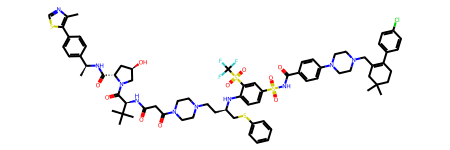

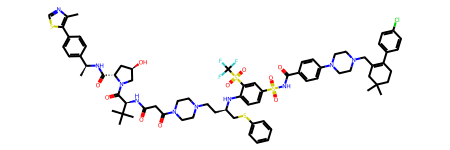

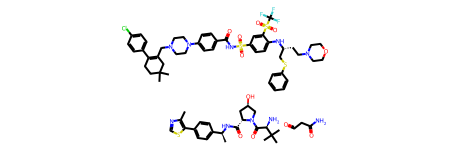

In [61]:
def same_atom_counts_and_types(
        smiles1: str,
        smiles2: str,
        get_atoms_diff: bool = False,
) -> bool | Dict[str, int]:
    """
    Check if two molecules have the same number and types of atoms.

    Args:
        smiles1 (str): SMILES notation for the first molecule.
        smiles2 (str): SMILES notation for the second molecule.
        get_atoms_diff (bool, optional): If True, returns the difference in atom counts. If False, returns if they match. Defaults to False.

    Returns:
        bool: True if the molecules have the same atom counts and types, False otherwise.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        if get_atoms_diff:
            raise ValueError("Invalid SMILES notation provided for one or both molecules.")
        else:
            return False
    atom_counts1, atom_counts2 = {}, {}
    for atom in mol1.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts1[atom.GetSymbol()] = atom_counts1.get(atom.GetSymbol(), 0) + 1
    for atom in mol2.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts2[atom.GetSymbol()] = atom_counts2.get(atom.GetSymbol(), 0) + 1
    # atom_counts1 = {atom.GetSymbol(): atom.GetIdx() for atom in mol1.GetAtoms()}
    # atom_counts2 = {atom.GetSymbol(): atom.GetIdx() for atom in mol2.GetAtoms()}
    if get_atoms_diff:
        tmp = {}
        for atom in atom_counts1.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        for atom in atom_counts2.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        return tmp # abs(atom_counts1.get('O', 0) - atom_counts2.get('O', 0))
    else:
        num_atoms1 = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol1)
        num_atoms2 = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol2)
        return (atom_counts1 == atom_counts2) & (num_atoms1 == num_atoms2)

x = protac_pedia_df.iloc[0]
oxygen_diff = same_atom_counts_and_types(
    x['PROTAC SMILES'],
    '.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']]),
    get_atoms_diff=True,
)
print(oxygen_diff)
safe_display(Chem.MolFromSmiles(x['PROTAC SMILES']))
safe_display(Chem.MolFromSmiles(x['PROTAC SMILES']))
safe_display(Chem.MolFromSmiles('.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']])))

## Substructure Search

In [62]:
def remove_bond_attachments(smiles):
    smiles = smiles.replace(f'[*:{POI_ATTACHMENT_ID}]=', f'[*:{POI_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'[*:{POI_ATTACHMENT_ID}]#', f'[*:{POI_ATTACHMENT_ID}]')

    smiles = smiles.replace(f'[*:{E3_ATTACHMENT_ID}]=', f'[*:{E3_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'[*:{E3_ATTACHMENT_ID}]#', f'[*:{E3_ATTACHMENT_ID}]')

    smiles = smiles.replace(f'=[*:{POI_ATTACHMENT_ID}]', f'[*:{POI_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'#[*:{POI_ATTACHMENT_ID}]', f'[*:{POI_ATTACHMENT_ID}]')

    smiles = smiles.replace(f'=[*:{E3_ATTACHMENT_ID}]', f'[*:{E3_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'#[*:{E3_ATTACHMENT_ID}]', f'[*:{E3_ATTACHMENT_ID}]')
    
    return smiles


def remove_attachment_points(smiles: str) -> str:
    """
    Remove attachment points labeled as "[*:1]" or "[*:2]" from a molecule represented by SMILES.

    Args:
        smiles (str): The SMILES notation of the molecule.

    Returns:
        str: SMILES notation of the molecule with attachment points removed.
    """
    # TODO: Barely removing the attachment points can result in
    # invalid SMILES... Why?
    smiles = remove_bond_attachments(smiles)
    return smiles.replace(f"[*:{POI_ATTACHMENT_ID}]", "").replace(f"[*:{E3_ATTACHMENT_ID}]", "")


def add_e3_poi_directionality_v2(row: pd.Series) -> pd.Series:
    """ This gets both E3 and POI with attachment points.
    
    Args:
        row (pd.Series): A row from a DataFrame.

    Returns:
        pd.Series: The same row with the E3 and POI ligands with attachment points
    """
    # Set default values
    e3_smiles_dir = float('nan')
    poi_smiles_dir = float('nan')
    row['E3 Binder SMILES with direction'] = e3_smiles_dir
    row['POI Ligand SMILES with direction'] = poi_smiles_dir

    # Get the molecules
    protac_mol = Chem.MolFromSmiles(row['PROTAC SMILES'])
    poi_mol = Chem.MolFromSmiles(row['POI Ligand SMILES'])
    e3_mol = Chem.MolFromSmiles(row['E3 Binder SMILES'])
    linker_mol = Chem.MolFromSmarts(row['Linker SMILES'])

    # If any of the above is None, return the row as is
    if any([protac_mol is None, poi_mol is None, e3_mol is None, linker_mol is None]):
        return row

    # Remove the E3 and POI ligands from the PROTAC molecule to get the R-groups
    rgroups_linker_poi_mol = Chem.DeleteSubstructs(
        protac_mol,
        e3_mol,
        # protac_mol.GetSubstructMatch(e3_mol),
        # labelByIndex=False,
        # replaceDummies=False,
    )
    rgroups_linker_e3_mol = Chem.DeleteSubstructs(
        protac_mol,
        poi_mol,
        # protac_mol.GetSubstructMatch(poi_mol),
        # labelByIndex=False,
        # replaceDummies=False,
    )

    # rgroups_linker_poi_mol = Chem.MolFromSmiles(Chem.MolToSmiles(rgroups_linker_poi_mol).replace('[1*]', '')) # .replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]'))
    # rgroups_linker_e3_mol = Chem.MolFromSmiles(Chem.MolToSmiles(rgroups_linker_e3_mol).replace('[1*]', '')) # .replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]'))

    e3_mol_dir = Chem.ReplaceCore(protac_mol, rgroups_linker_poi_mol, labelByIndex=False, replaceDummies=False)
    poi_mol_dir = Chem.ReplaceCore(protac_mol, rgroups_linker_e3_mol, labelByIndex=False, replaceDummies=False)

    # Add attachment points to the E3 ligand
    e3_smiles_dir = Chem.MolToSmiles(e3_mol_dir, canonical=True)
    # Remove the linker from the R-groups instead
    if len(e3_smiles_dir.split(".")) > 2 or len(e3_smiles_dir.split("*")) > 2:
        e3_mol_dir = Chem.ReplaceCore(rgroups_linker_e3_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        if len(e3_smiles_dir.split(".")) > 2:
            print(f'ERROR: E3 has multiple substructures: {e3_smiles_dir}')
        if len(e3_smiles_dir.split("*")) > 2:
            print(f'ERROR: E3 has multiple attachment points: {e3_smiles_dir}')
        
    for i, substruct_smiles in enumerate(e3_smiles_dir.split(".")):
        substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
        if not substruct_mol:
            return row

        if substruct_mol.HasSubstructMatch(e3_mol):
            e3_smiles_dir = substruct_smiles.replace(f'[{i+1}*]', f'[*:{E3_ATTACHMENT_ID}]')
            break

    # Add attachment points to the POI ligand
    poi_smiles_dir = Chem.MolToSmiles(poi_mol_dir, canonical=True)
    # Remove the linker from the R-groups instead
    if len(e3_smiles_dir.split(".")) > 2 or len(e3_smiles_dir.split("*")) > 2:
        poi_mol_dir = Chem.ReplaceCore(rgroups_linker_poi_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        if len(poi_smiles_dir.split(".")) > 2:
            print(f'ERROR: POI has multiple substructures: {poi_smiles_dir}')
        if len(poi_smiles_dir.split("*")) > 2:
            print(f'ERROR: POI has multiple attachment points: {poi_smiles_dir}')

    for i, substruct_smiles in enumerate(poi_smiles_dir.split(".")):
        substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
        if not substruct_mol:
            poi_smiles_dir = float('nan')
            safe_display(protac_mol)
            safe_display(poi_mol)
            safe_display(linker_mol)
            safe_display(e3_mol)
            print(f'poi smiles:   {row["POI Ligand SMILES"]}')
            print(f'poi modified: {substruct_smiles}')
            print('=' * 80)
        else:
            if substruct_mol.HasSubstructMatch(poi_mol):
                poi_smiles_dir = substruct_smiles.replace(f'[{i+1}*]', f'[*:{POI_ATTACHMENT_ID}]')
                break

    # Set the output fields
    row['E3 Binder SMILES with direction'] = e3_smiles_dir
    row['POI Ligand SMILES with direction'] = poi_smiles_dir

    return row


def reset_row(
        row: pd.Series,
        how: Literal['all', 'poi', 'e3', 'linker'] = 'all',
) -> pd.Series:
    """ Reset the row to the original values.

    Args:
        row (pd.Series): A row from a DataFrame.

    Returns:
        pd.Series: The same row with the E3 and POI ligands with attachment points
    """
    if how == 'poi' or how == 'all':
        row['POI Ligand ID'] = float('nan')
        row['POI Ligand SMILES'] = float('nan')
        row['POI Ligand SMILES with direction'] = float('nan')
    if how == 'e3' or how == 'all':
        row['E3 Binder ID'] = float('nan')
        row['E3 Binder SMILES'] = float('nan')
        row['E3 Binder SMILES with direction'] = float('nan')
    if how == 'linker' or how == 'all':
        row['Linker ID'] = float('nan')
        row['Linker SMILES'] = float('nan')
        row['Linker SMILES with direction'] = float('nan')
    row['poi_exact_match'] = False
    row['e3_exact_match'] = False
    return row


def get_substructures_from_dict(
        row: pd.Series,
        poi_dict: pd.DataFrame,
        e3_dict: pd.DataFrame,
) -> pd.Series:
    """ Get the substructures of a PROTAC from the dictionaries.
    
    Args:
        row (pd.Series): A row from the PROTAC-Pedia DataFrame.
        poi_dict (pd.DataFrame): The dictionary of POI ligands.
        e3_dict (pd.DataFrame): The dictionary of E3 binders.
    
    Returns:
        pd.Series: The row with the substructures added.
    """
    # The algorithm is as follows:
    # 1. Given the molecule of the PROTAC, try to match a POI from the POI dictionary first.
    # 2. If the POI is found, get the R-groups, i.e., the E3 and linker together.
    # 3. If the E3 from the E3 dictionary is found in the R-groups, get the linker as the remaining part.

    # Set default values
    row = reset_row(row)

    protac_smiles = row["PROTAC SMILES"]
    protac_mol = row["PROTAC Molecule"]
    rgroups_smiles = ""


    # linker_matches = linker_dict["Molecule"].apply(lambda linker: protac_mol.HasSubstructMatch(linker))
    # # Sort the Linker matches by the number of atoms in the molecule
    # if linker_matches.any():
    #     linker_matches = linker_dict[linker_matches]
    #     linker_matches = linker_matches.sort_values(by="Molecule", key=lambda s: s.apply(lambda m: m.GetNumAtoms()))

    #     for _, row_l in linker_matches.iterrows():
    #         linker_mol = row_l["Molecule"]
    #         rgroups_mol = Chem.ReplaceCore(protac_mol, linker_mol, protac_mol.GetSubstructMatch(linker_mol), labelByIndex=False)

    #         e3_poi_mol = Chem.GetMolFrags(rgroups_mol, asMols=True)
    #         if len(e3_poi_mol) != 2:
    #             continue
    #         else:
    #             e3_mol, poi_mol = e3_poi_mol
    #             e3_mol_dir = Chem.ReplaceSidechains(protac_mol, e3_mol, useChirality=True)
    #             poi_mol_dir = Chem.ReplaceSidechains(protac_mol, poi_mol, useChirality=True)
    #             print(Chem.MolToSmiles(e3_mol_dir, canonical=True))
    #             print(Chem.MolToSmiles(poi_mol_dir, canonical=True))
    #             break


    # Extract the POI Ligands that are a substructure match in PROTAC molecule
    poi_matches = poi_dict['POI Ligand Molecule'].apply(lambda poi: protac_mol.HasSubstructMatch(poi))
    poi_matches = poi_dict[poi_matches]
    # Return if there are no matches, otherwise get the R-groups
    if poi_matches.empty:
        return row
    row['poi_exact_match'] = True
    all3_matching = False

    # Sort the POI matches by the number of atoms in the molecule
    poi_matches = poi_matches.sort_values(by='POI Ligand Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

    for _, row_p in poi_matches.iterrows():
        # Get the R-groups, i.e., E3 and Linker
        poi_mol = row_p['POI Ligand Molecule']
        rgroups_mol = Chem.ReplaceCore(protac_mol, poi_mol, protac_mol.GetSubstructMatch(poi_mol), labelByIndex=False)
        if len(Chem.GetMolFrags(rgroups_mol)) != 1:
            row = reset_row(row)
            continue

        rgroups_smiles = Chem.MolToSmiles(rgroups_mol, canonical=True)
        rgroups_smiles = rgroups_smiles.replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')

        # If there are 'floating' groups, i.e., non perfect matches, then go to
        # the next POI match
        if len(rgroups_smiles.split('*')) != 2:
            row = reset_row(row)
            continue

        poi_mol_dir = Chem.ReplaceSidechains(protac_mol, poi_mol, useChirality=True)
        if pd.isnull(poi_mol_dir):
            row = reset_row(row)
            continue

        # Set the POI based on the found one
        row['POI Ligand ID'] = row_p['POI Ligand ID']
        row['POI Ligand SMILES'] = Chem.MolToSmiles(poi_mol, canonical=True)
        row['POI Ligand SMILES with direction'] = Chem.MolToSmiles(poi_mol_dir, canonical=True).replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')

        # Check that there are no more than one '*' in the POI ligand SMILES
        if row['POI Ligand SMILES with direction'].count('*') > 1:
            row = reset_row(row)
            continue

        # Extract the E3 Binders that are a substructure match in R-groups
        e3_matches = e3_dict['E3 Binder Molecule'].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
        e3_matches = e3_dict[e3_matches]
        if e3_matches.empty:
            row = reset_row(row)
            continue
        rgroups_mol = Chem.MolFromSmiles(rgroups_smiles)

        # Sort the E3 matches by the number of atoms in the molecule
        e3_matches = e3_matches.sort_values(by='E3 Binder Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

        for _, row_e in e3_matches.iterrows():
            e3_mol = row_e['E3 Binder Molecule']
            if not rgroups_mol.HasSubstructMatch(e3_mol):
                row = reset_row(row, how='e3')
                continue

            # Get the linker from the E3 and R-groups
            linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, rgroups_mol.GetSubstructMatch(e3_mol), labelByIndex=False)
            if linker_mol is None:
                linker_mol = Chem.ReplaceSidechains(rgroups_mol, e3_mol)
                if linker_mol is None:
                    continue
            linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True)
            linker_smiles = linker_smiles.replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')

            # If there are 'floating' groups other than the linker, continue
            if '.' in linker_smiles:
                row = reset_row(row, how='e3')
                continue
            if not protac_mol.HasSubstructMatch(Chem.MolFromSmarts(linker_smiles)):
                row = reset_row(row, how='e3')
                continue

            # Check if the atoms of the PROTAC and its substructures are the
            # same, if not, continue to the next E3 match found (if there
            # are no more, then continue to the next POI match).
            substructs_smiles = '.'.join([
                linker_smiles,
                row_p['POI Ligand SMILES'],
                row_e['E3 Binder SMILES'],
            ])
            if not same_atom_counts_and_types(protac_smiles, substructs_smiles):
                row = reset_row(row, how='e3')
                continue

            e3_mol_dir = Chem.ReplaceSidechains(rgroups_mol, e3_mol, useChirality=True)
            if pd.isnull(e3_mol_dir):
                row['E3 Binder SMILES'] = Chem.MolToSmiles(e3_mol, canonical=True)
                row['Linker SMILES'] = linker_smiles
                row = add_e3_poi_directionality_v2(row.copy())
                if pd.isnull(row['E3 Binder SMILES with direction']):
                    row = reset_row(row, how='e3')
                    row = reset_row(row, how='linker')
                    continue
                e3_mol_dir = Chem.MolFromSmiles(row['E3 Binder SMILES with direction'])

            # print(Chem.MolToSmiles(e3_mol, canonical=True))
            # print(Chem.MolToSmiles(e3_mol_dir, canonical=True))
            # # Check if mol are equal
            # # Remove dummy atoms from e3_mol_dir
            # e3_mol_dir = Chem.MolFromSmiles(Chem.MolToSmiles(e3_mol_dir, canonical=True).replace('[1*]', ''))
            # if Chem.MolToInchi(e3_mol) == Chem.MolToInchi(e3_mol_dir):
            #     print('Molecules are equal')
            # display(e3_mol)
            # display(e3_mol_dir)
            # print('-' * 80)

            # Set the E3 based on the found one
            row['e3_exact_match'] = True
            row['E3 Binder ID'] = row_e['E3 Binder ID']
            row['E3 Binder SMILES'] = Chem.MolToSmiles(e3_mol, canonical=True)
            row['E3 Binder SMILES with direction'] = Chem.MolToSmiles(e3_mol_dir, canonical=True).replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')
            row['Linker SMILES with direction'] = linker_smiles
            row['Linker SMILES'] = remove_attachment_points(linker_smiles)

            # Update the linker dictionary if not there
            if row['Linker SMILES'] not in smiles2id_dict['Linker']:
                smiles2id_dict['Linker'][row['Linker SMILES']] = len(smiles2id_dict['Linker'])
            row['Linker SMILES ID'] = smiles2id_dict['Linker'][row['Linker SMILES']]

            is_reassembled = check_substructs(
                protac_smiles=protac_smiles,
                poi_smiles=row['POI Ligand SMILES with direction'],
                linker_smiles=row['Linker SMILES with direction'],
                e3_smiles=row['E3 Binder SMILES with direction'],
            )
            if not is_reassembled:
                row = reset_row(row, how='e3')
                row = reset_row(row, how='linker')
                continue

            all3_matching = True
            break

        # If all 3 components are matching, break and return the updated row
        if all3_matching:
            break

        # # Extract the Linkers that are a substructure match in R-groups
        # linker_matches = linker_dict['Molecule'].apply(lambda linker: protac_mol.HasSubstructMatch(linker))
        # linker_matches = linker_dict[linker_matches]
        # if linker_matches.empty:
        #     continue
        # rgroups_mol = Chem.MolFromSmiles(rgroups_smiles)

        # # Sort the Linker matches by the number of atoms in the molecule
        # linker_matches = linker_matches.sort_values(by='Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

        # for _, row_l in linker_matches.iterrows():
        #     linker_mol = row_l['Molecule']
        #     if not rgroups_mol.HasSubstructMatch(linker_mol):
        #         continue

        #     # Get the linker from the E3 and R-groups
        #     e3_mol = Chem.ReplaceCore(rgroups_mol, linker_mol, rgroups_mol.GetSubstructMatch(linker_mol), labelByIndex=False)
        #     if e3_mol is None:
        #         e3_mol = Chem.ReplaceSidechains(rgroups_mol, linker_mol)
        #         if e3_mol is None:
        #             continue
        #     e3_smiles = Chem.MolToSmiles(e3_mol, canonical=True)
        #     e3_smiles = e3_smiles.replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')

        #     # If there are 'floating' groups other than the linker, continue
        #     if '.' in e3_smiles:
        #         continue
        #     if not protac_mol.HasSubstructMatch(Chem.MolFromSmarts(e3_smiles)):
        #         continue

        #     # Check if the atoms of the PROTAC and its substructures are the
        #     # same, if not, continue to the next E3 match found (if there
        #     # are no more, then continue to the next POI match).
        #     substructs = [
        #         row_l['Linker SMILES'],
        #         row_p['POI Ligand SMILES'],
        #         e3_smiles,
        #     ]
        #     substructs = '.'.join(substructs)
        #     if not same_atom_counts_and_types(protac_smiles, substructs):
        #         continue

        #     e3_mol_dir = Chem.ReplaceSidechains(rgroups_mol, e3_mol)
        #     display(linker_mol)
        #     display(e3_mol)
        #     display(e3_mol_dir)

        #     # Set the E3 based on the found one
        #     row['e3_exact_match'] = True
        #     row['E3 Binder SMILES'] = Chem.MolToSmiles(e3_mol, canonical=True)
        #     row['E3 Binder SMILES with direction'] = Chem.MolToSmiles(e3_mol_dir, canonical=True).replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')
        #     row['Linker ID'] = row_l['ID']
        #     row['Linker SMILES with direction'] = linker_smiles
        #     row['Linker SMILES'] = remove_attachment_points(linker_smiles)

        #     if not check_substructs(protac_smiles, row['POI Ligand SMILES with direction'], row['Linker SMILES with direction'], row['E3 Binder SMILES with direction']):
        #         continue

        #     all3_matching = True
        #     break

        # # If all 3 components are matching, break and return the updated row
        # if all3_matching:
        #     break

    return row


smi_cols = ['E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
dir_cols = [f'{s} with direction' for s in smi_cols]

poi_dict = smiles2id_df['POI Ligand']
e3_dict = smiles2id_df['E3 Binder']

# NOTE: Remove the duplicates later by keeping the largest substructures

# ------------------------------------------------------------------------------

# pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
# db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
# protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# protac_curated_df = protac_curated_df.drop_duplicates(subset=['PROTAC SMILES'])

# tqdm.pandas(desc='Get substructures', postfix=None)
# protac_curated_df = protac_curated_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# protac_curated_df = protac_curated_df.dropna(subset=smi_cols)

# ------------------------------------------------------------------------------

print(f'Length of PROTAC-Pedia: {len(protac_pedia_df)}')
tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia = pedia.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
pedia = pedia.dropna(subset=smi_cols)
print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

print(f'Length of PROTAC-DB: {len(protac_db_df)}')
tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
db = db.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
db = db.dropna(subset=smi_cols)
print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# entries that matched already with its entries
protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
protac_curated_df = protac_curated_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

safe_display(protac_curated_df[smi_cols].head())
safe_display(protac_curated_df[dir_cols].head())
print(f'Length of PROTAC-Curated: {len(protac_curated_df)}')

Length of PROTAC-Pedia: 1203


Get substructures for PROTAC-Pedia: 100%|███| 1178/1178 [00:25<00:00, 47.11it/s]


Length of PROTAC-Pedia: 681 (after substructure matching)
Length of PROTAC-DB: 5388


Get substructures for PROTAC-DB: 100%|██████| 3270/3270 [01:01<00:00, 52.79it/s]

Length of PROTAC-DB: 1647 (after substructure matching)


,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
0,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
1,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCOCCOC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
2,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,C,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
3,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
4,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCCC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...


,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CCC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@...
1,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CCOCCOC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@...
2,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]C[*:1],[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@...
3,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@...
4,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CCCC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@...


Length of PROTAC-Curated: 2328


**NOTE**: the duplicates in the dataframes are not removed according to their substructures (with direction). The reason is that there might be _different PROTACs_ for which the _same_ substructures are used, but linked together with _different bonds_.

Double check that all substructures can be re-assembled into the original PROTACs:

In [63]:
def check_dataframe(df: pd.DataFrame) -> pd.Series:
    tqdm.pandas(desc='Checking dataframe')
    return df.progress_apply(lambda x: check_substructs(
            protac_smiles=x['PROTAC SMILES'],
            poi_smiles=x['POI Ligand SMILES with direction'],
            linker_smiles=x['Linker SMILES with direction'],
            e3_smiles=x['E3 Binder SMILES with direction'],
        ), axis=1)

print('Number of incorrect re-assembled samples:', len(protac_curated_df[~check_dataframe(protac_curated_df)]))

Checking dataframe:   0%|                              | 0/2328 [00:00<?, ?it/s]

Checking dataframe: 100%|██████████████████| 2328/2328 [00:20<00:00, 113.57it/s]

Number of incorrect re-assembled samples: 0


## Add Removed Stereochemistry PROTACs

In [64]:
tqdm.pandas(desc='Removing stereochemistry', postfix=None)

pedia_nostereo_df = protac_pedia_df.copy()
pedia_nostereo_df['PROTAC SMILES'] = pedia_nostereo_df['PROTAC SMILES'].progress_apply(remove_stereo)
pedia_nostereo_df = pedia_nostereo_df.dropna(subset=['PROTAC SMILES'])

db_nostereo_df = protac_db_df.copy()
db_nostereo_df['PROTAC SMILES'] = db_nostereo_df['PROTAC SMILES'].progress_apply(remove_stereo)
db_nostereo_df = db_nostereo_df.dropna(subset=['PROTAC SMILES'])

poi_dict = smiles2id_df['POI Ligand'].copy()
e3_dict = smiles2id_df['E3 Binder'].copy()

Removing stereochemistry:   0%|                        | 0/1203 [00:00<?, ?it/s]

Removing stereochemistry: 100%|███████████| 5388/5388 [00:03<00:00, 1714.19it/s]


In [65]:
pedia = pedia_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
db = db_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
curated_nostereo_df = pd.concat([db, pedia], axis=0, ignore_index=True)
curated_nostereo_df = curated_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])

# Get all entries with SMILES not in protac_curated_df
curated_nostereo_df = curated_nostereo_df[~curated_nostereo_df['PROTAC SMILES'].isin(protac_curated_df['PROTAC SMILES'])]

tqdm.pandas(desc='Get substructures', postfix=None)
curated_nostereo_df = curated_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
curated_nostereo_df = curated_nostereo_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

# print(f'Length of PROTAC-Pedia: {len(pedia_nostereo_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
# pedia = pedia_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# pedia = pedia.dropna(subset=smi_cols)
# print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

# print(f'Length of PROTAC-DB: {len(db_nostereo_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
# db = db_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# db = db.dropna(subset=smi_cols)
# print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# # NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# # entries that matched already with its entries
# curated_nostereo_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# curated_nostereo_df = curated_nostereo_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

safe_display(curated_nostereo_df[smi_cols].head())
safe_display(curated_nostereo_df[dir_cols].head())
print(f'Length of PROTAC-Curated: {len(curated_nostereo_df)} (without stereochemistry)')

Get substructures:   0%|                               | 0/2728 [00:00<?, ?it/s]

Get substructures: 100%|████████████████████| 2728/2728 [01:41<00:00, 26.84it/s]


,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
47,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,CCC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
53,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,CC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
54,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,COCCOC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
55,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,COCCOCCOC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
111,CNC(=O)C[C@H](NC(=O)[C@H]1C[C@H](O)CN1C(=O)[C@...,CCCCCCC,CNC(=O)c1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)...


,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
47,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,[*:2]CCC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
53,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]CC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
54,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]COCCOC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
55,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]COCCOCCOC[*:1],[*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
111,Cc1cc(C(C(=O)N2CC(O)CC2C(=O)NC(CC(=O)NC[*:2])c...,[*:2]CCCCCCC[*:1],[*:1]CNC(=O)c1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)...


Length of PROTAC-Curated: 224 (without stereochemistry)


Double check that all substructures can be re-assembled into the original PROTACs:

In [66]:
print('Number of incorrect re-assembled samples:', len(curated_nostereo_df[~check_dataframe(curated_nostereo_df)]))

Checking dataframe:   0%|                               | 0/224 [00:00<?, ?it/s]

Checking dataframe: 100%|█████████████████████| 224/224 [00:03<00:00, 74.14it/s]

Number of incorrect re-assembled samples: 0


## Remove Duplicates

Check if there are and how any duplicates look like in the PROTAC SMIILES column:

In [67]:
print(f'Number of duplicates in PROTAC SMILES: {protac_curated_df["PROTAC SMILES"].duplicated().sum()}')

# Display duplicated PROTACs and their substructures
i = 0
for protac_smiles, group in protac_curated_df.drop_duplicates(subset=dir_cols).groupby("PROTAC SMILES"):
    # Reset index and print every row in the group
    group = group.reset_index().drop_duplicates(subset=smiles_cols + dir_cols)
    if len(group) == 1:
        continue
    print(f'PROTAC: {protac_smiles}')
    print("-" * 80)
    for c in dir_cols:
        for s in group[c].unique():
            print(f'\t{c.capitalize().split(" ")[0]}:\t{s}')
        print('')
    print("=" * 80)
    print('')
    i += 1
    if i > 10:
        break

Number of duplicates in PROTAC SMILES: 419


Let's remove duplicates for the same PROTAC, by keeping the entry with the longest SMILES (in terms of atoms):

In [68]:
substruct_smiles_cols = [
    'POI Ligand SMILES',
    'Linker SMILES',
    'E3 Binder SMILES',
]
relevant_cols = substruct_smiles_cols + dir_cols

final_df = pd.concat([protac_curated_df, curated_nostereo_df], axis=0, ignore_index=True)

no_duplicates_df = []
no_duplicates_sr = []
i = 0
for protac_smiles, group in final_df.groupby("PROTAC SMILES"):
    # Reset index and print every row in the group
    if len(group) == 1:
        no_duplicates_df.append(group.copy())
        continue

    # if i < 5:
    #     print(f'PROTAC: {protac_smiles}')
    #     display(group)
    #     display(group.reset_index().drop_duplicates(subset=dir_cols))
    #     print('-' * 80)
    # group = group.reset_index().drop_duplicates(subset=dir_cols)

    # Loop over the rows in the group to get the one with the longest linker
    max_atoms = 0
    row_w_longest_linker = None
    for j, row in group.iterrows():
        # Get the number of atoms in the linker substructures
        linker_mol = Chem.MolFromSmiles(row["Linker SMILES with direction"])
        num_atoms = Chem.rdMolDescriptors.CalcNumHeavyAtoms(linker_mol)
        # NOTE: We leave in empty linkers (i.e., with no atoms)
        if num_atoms >= max_atoms:
            max_atoms = num_atoms
            row_w_longest_linker = row.copy()
            if i < 5:
                print(f'Linker n.{j}: {row["Linker SMILES with direction"]}')

    # if row_w_longest_linker is None:
    #     safe_display(group.iloc[0]['PROTAC SMILES'])
    #     safe_display(group.iloc[0]['POI Ligand SMILES with direction'])
    #     safe_display(group.iloc[1]['POI Ligand SMILES with direction'])
    #     safe_display(group[dir_cols])

    if i < 5:
        print(f'Linker with max atoms: {row_w_longest_linker["Linker SMILES with direction"]} ({max_atoms} atoms)')
        print('')
    # Append the row with the longest linker
    no_duplicates_sr.append(row_w_longest_linker.copy())
    i += 1

# Concatenate the DataFrames
final_no_duplicates_df = pd.concat(no_duplicates_df, axis=0, ignore_index=True)
final_no_duplicates_sr = pd.DataFrame(no_duplicates_sr)
final_no_duplicates_df = pd.concat([final_no_duplicates_df, final_no_duplicates_sr], axis=0, ignore_index=True)

print(f'Lenght before removing duplicates: {len(final_df)}')
num_duplicates = final_df["PROTAC SMILES"].duplicated().sum()
print(f'Number of duplicates in PROTAC SMILES: {num_duplicates}')
print(f'Length after removal: {len(final_no_duplicates_df)} (Expected: {len(final_df) - num_duplicates})')

final_no_duplicates_df = final_no_duplicates_df.dropna(subset=dir_cols)
print(f'Length after dropna: {len(final_no_duplicates_df)}')

final_no_duplicates_df = final_no_duplicates_df.drop_duplicates(subset='PROTAC SMILES')
print(f'Length after drop_duplicates: {len(final_no_duplicates_df)}')

num_duplicates = final_no_duplicates_df["PROTAC SMILES"].duplicated().sum()
print(f'Number of duplicates in PROTAC SMILES: {num_duplicates}')
final_no_duplicates_df.head()[dir_cols]

Linker n.933: [*:2]CNC(=O)C[*:1]
Linker n.2172: [*:2]CNC(=O)C[*:1]
Linker with max atoms: [*:2]CNC(=O)C[*:1] (5 atoms)

Linker n.936: [*:2]COCCNC(=O)C[*:1]
Linker n.2175: [*:2]COCCNC(=O)C[*:1]
Linker with max atoms: [*:2]COCCNC(=O)C[*:1] (8 atoms)

Linker n.931: [*:2]COCCOCCNC(=O)C[*:1]
Linker n.2170: [*:2]COCCOCCNC(=O)C[*:1]
Linker with max atoms: [*:2]COCCOCCNC(=O)C[*:1] (11 atoms)

Linker n.934: [*:2]COCCC[*:1]
Linker n.2173: [*:2]COCCC[*:1]
Linker with max atoms: [*:2]COCCC[*:1] (5 atoms)

Linker n.932: [*:2]COCC[*:1]
Linker n.2171: [*:2]COCC[*:1]
Linker with max atoms: [*:2]COCC[*:1] (4 atoms)

Lenght before removing duplicates: 2552
Number of duplicates in PROTAC SMILES: 419
Length after removal: 2133 (Expected: 2133)
Length after dropna: 2133
Length after drop_duplicates: 2133
Number of duplicates in PROTAC SMILES: 0


,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]CCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCN...
1,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]CCCCNC(=O)[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...
2,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]CCCCCNC(=O)[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...
3,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]OCCOCCNC(=O)[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...
4,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]CCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...


## Cleanup Dummy Atoms

Some of the dummy atoms entries might not be "perfect", _e.g._, instead of `[*:1]` they might be `[1:*1]`. Let's fix this:

In [69]:
# For each substructure column with direction, check the dummy atoms with a
# regex, i.e, if there is a '*' within [] brackets: if there are not [*:1] nor [*:2],
# convert them to the correct attachment points.
dummy_rgx = re.compile(r'\[\*[\:\d+]*\]')

for col in dir_cols:
    print('-' * 80)
    print(f'Checking {col}')
    print('-' * 80)
    for smiles in final_no_duplicates_df[col].unique():
        if not dummy_rgx.search(smiles):
            print(f'ERROR: No dummy atoms found in: {smiles}')
        for match in dummy_rgx.finditer(smiles):
            # Check if match not equal to '[*:1]' nor '[*:2]'
            if match.group() not in ['[*:1]', '[*:2]']:
                new_smiles = smiles.replace(match.group(), f'[*:{match.group(1)}]')
                print(f'{smiles} -> {new_smiles}')
            # final_no_duplicates_df[col] = final_no_duplicates_df[col].replace(smiles, new_smiles)

--------------------------------------------------------------------------------
Checking E3 Binder SMILES with direction
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Checking Linker SMILES with direction
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Checking POI Ligand SMILES with direction
--------------------------------------------------------------------------------


In [70]:
print(f'Lenght of final_no_duplicates_df: {len(final_no_duplicates_df)}')
final_no_duplicates_df.head()[relevant_cols]

Lenght of final_no_duplicates_df: 2133


,POI Ligand SMILES,Linker SMILES,E3 Binder SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,C=CC(=O)N1CCC[C@H](n2c(Nc3ccccc3)nc3cnc(Nc4ccc...,CCCCC,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]CCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCN...
1,C=CC(=O)N1CCC[C@H](n2c(Nc3ccccc3)nc3cnc(Nc4ccc...,CCCCNC(=O),CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]CCCCNC(=O)[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...
2,C=CC(=O)N1CCC[C@H](n2c(Nc3ccccc3)nc3cnc(Nc4ccc...,CCCCCNC(=O),CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]CCCCCNC(=O)[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...
3,C=CC(=O)N1CCC[C@H](n2c(Nc3ccccc3)nc3cnc(Nc4ccc...,OCCOCCNC(=O),CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]OCCOCCNC(=O)[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...
4,C=CC(=O)N1CCC[C@H](n2c(Nc3ccccc3)nc3cnc(Nc4ccc...,CCCC,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,[*:2]CCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n([C@H]5...


In [71]:
print('Number of incorrect re-assembled samples:', len(final_no_duplicates_df[~check_dataframe(final_no_duplicates_df)]))

Checking dataframe:   0%|                              | 0/2133 [00:00<?, ?it/s]

Checking dataframe: 100%|██████████████████| 2133/2133 [00:19<00:00, 109.39it/s]

Number of incorrect re-assembled samples: 0


## Add Missing IDs

In [72]:
def add_to_dict(
        smiles: str,
        smiles2id_dict: Dict[str, Dict[str, int]],
        substruct: str,
) -> Dict[str, Dict[str, int]]:
    """ Add a SMILES to an ID dictionary.

    Args:
        smiles (str): The SMILES to add to the dictionary.
        smiles2id_dict (Dict[str, Dict[str, int]]): The dictionary with the SMILES to ID mapping.
        substruct (str): The column name of the dictionary to add the SMILES to.

    Returns:
        Dict[str, Dict[str, int]]: The updated dictionary.
    """
    if smiles not in smiles2id_dict[substruct]:
        smiles2id_dict[substruct][smiles] = len(smiles2id_dict[substruct])
    return smiles2id_dict

print('Updating the dictionaries...')
for substruct, smiles2id in smiles2id_dict.items():
    print(f'{substruct}: {len(smiles2id)}')

for substruct, smiles2id in smiles2id_dict.items():
    smi_col = f'{substruct} SMILES'
    smi_id_col = f'{substruct} ID'
    for smi, smi_id in zip(final_no_duplicates_df[smi_col], final_no_duplicates_df[smi_id_col]):
        if pd.isnull(smi_id):
            smiles2id_dict = add_to_dict(smi, smiles2id_dict, substruct)

print('-' * 80)
for substruct, smiles2id in smiles2id_dict.items():
    print(f'{substruct}: {len(smiles2id)}')

Updating the dictionaries...
PROTAC: 5680
POI Ligand: 871
Linker: 4108
E3 Binder: 257
--------------------------------------------------------------------------------
PROTAC: 5680
POI Ligand: 871
Linker: 4108
E3 Binder: 257


In [73]:
for substruct in ['PROTAC', 'E3 Binder', 'Linker', 'POI Ligand']:
    smiles2id = smiles2id_dict[substruct]
    final_no_duplicates_df[f'{substruct} ID'] = final_no_duplicates_df[f'{substruct} SMILES'].apply(lambda x: smiles2id.get(x, float('nan')))
    final_no_duplicates_df[f'{substruct} ID'] = final_no_duplicates_df[f'{substruct} ID'].apply(lambda x: x if pd.isnull(x) else int(x))

# Display rows with NaN values in the relevant columns
final_no_duplicates_df[final_no_duplicates_df[relevant_cols].isnull().any(axis=1)][relevant_cols + smi_cols]

,POI Ligand SMILES,Linker SMILES,E3 Binder SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES


In [74]:
print('Number of incorrect re-assembled samples:', len(final_no_duplicates_df[~check_dataframe(final_no_duplicates_df)]))

Checking dataframe: 100%|██████████████████| 2133/2133 [00:19<00:00, 109.35it/s]

Number of incorrect re-assembled samples: 0


## Save to CSV

In [75]:
# Make dir if not existing
os.makedirs(os.path.join(data_dir, 'processed'), exist_ok=True)
relevant_cols = [
    'PROTAC ID',
    'PROTAC SMILES',
    'E3 Binder ID',
    'E3 Binder SMILES',
    'E3 Binder SMILES with direction',
    'Linker ID',
    'Linker SMILES',
    'Linker SMILES with direction',
    'POI Ligand ID',
    'POI Ligand SMILES',
    'POI Ligand SMILES with direction',
]
final_filename = os.path.join(data_dir, 'processed', 'protacs_splitted_with_directionality.csv')
final_no_duplicates_df[relevant_cols].to_csv(final_filename, index=False, encoding='utf8')

# Get all unique PROTACs from PROTAC-DB and PROTAC-Pedia, then save the ones
# that are NOT in the final_no_duplicates_df PROTAC SMILES
db_unique = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia_unique = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia_nostereo_unique = pedia_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
db_nostereo_unique = db_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])

# Get the PROTACs that are not in the final_no_duplicates_df
tmp = pd.concat([
    db_unique,
    pedia_unique,
    pedia_nostereo_unique,
    db_nostereo_unique,
], axis=0, ignore_index=True).dropna(subset=['PROTAC SMILES'])
tmp = tmp.drop_duplicates(subset=['PROTAC SMILES'])
tmp = tmp[~tmp['PROTAC SMILES'].isin(final_no_duplicates_df['PROTAC SMILES'])]
tmp['PROTAC ID'] = tmp.apply(lambda x: smiles2id_dict['PROTAC'].get(x['PROTAC SMILES'], float('nan')), axis=1)
tmp = tmp[['PROTAC SMILES', 'PROTAC ID']]
# Save to CSV
not_splitted_filename = os.path.join(data_dir, 'processed', 'protacs_not_splitted.csv')
tmp.to_csv(not_splitted_filename, index=False, encoding='utf8')

# Reporting
print(f'Length of splitted PROTACs: {len(final_no_duplicates_df):,}')
print(f'Length of not splitted PROTACs: {len(tmp):,}')

Length of splitted PROTACs: 2,133
Length of not splitted PROTACs: 3,547


In [76]:
max_combinations = 1
# Save the dictionaries as CSV (from dataframes)
for substruct, smiles2id in smiles2id_dict.items():
    df = dict2df(smiles2id, substruct)
    substruct_name = substruct.split(' ')[0].lower()
    filename = os.path.join(data_dir, 'processed', f'dictionary_{substruct_name}.csv')
    df.to_csv(filename, index=False, encoding='utf8')
    print(f'Length of {substruct} dictionary: {len(df):,}')
    if substruct != 'PROTAC':
        max_combinations *= len(df)
print(f'Maximum number of PROTAC combinations: {max_combinations:,} ({len(smiles2id_dict["PROTAC"]) / max_combinations:%} covered)')

Length of PROTAC dictionary: 5,680
Length of POI Ligand dictionary: 871
Length of Linker dictionary: 4,108
Length of E3 Binder dictionary: 257
Maximum number of PROTAC combinations: 919,563,476 (0.000618% covered)
